# Example 6: 2-D VDERM quick start
Build a 2×2 grid of rectangular regions from scratch, assign density values,
run a VDERM deformation, and visualise the cartogram result.

This is the 2-D analog of Example 1 (the cube): we start from boundary points
defined programmatically rather than loaded from a geographic file.

In [1]:
import pyVDERM as vd
import numpy as np

### Create four rectangular regions

We define four 1×1 squares arranged in a 2×2 pattern and sample points along
each perimeter.  These boundary points are the "map" that will be deformed —
the 2-D equivalent of the cube's surface point cloud.

```
┌──────┬──────┐
│  C   │  D   │  y ∈ [1, 2]
│  ρ=2 │ ρ=10 │
├──────┼──────┤
│  A   │  B   │  y ∈ [0, 1]
│  ρ=1 │  ρ=5 │
└──────┴──────┘
 x∈[0,1] x∈[1,2]
```

In [2]:
def region_boundary(x0, x1, y0, y1, n=40):
    """Return n points sampled along the perimeter of a rectangle."""
    bottom = np.column_stack([np.linspace(x0, x1, n), np.full(n, y0)])
    top    = np.column_stack([np.linspace(x0, x1, n), np.full(n, y1)])
    left   = np.column_stack([np.full(n, x0), np.linspace(y0, y1, n)])
    right  = np.column_stack([np.full(n, x1), np.linspace(y0, y1, n)])
    return np.vstack([bottom, top, left, right])

A = region_boundary(0, 1, 0, 1)   # lower-left,  rho = 1
B = region_boundary(1, 2, 0, 1)   # lower-right, rho = 5
C = region_boundary(0, 1, 1, 2)   # upper-left,  rho = 2
D = region_boundary(1, 2, 1, 2)   # upper-right, rho = 10

map_points = np.vstack([A, B, C, D])
print(f"Total map boundary points: {len(map_points)}")

Total map boundary points: 640


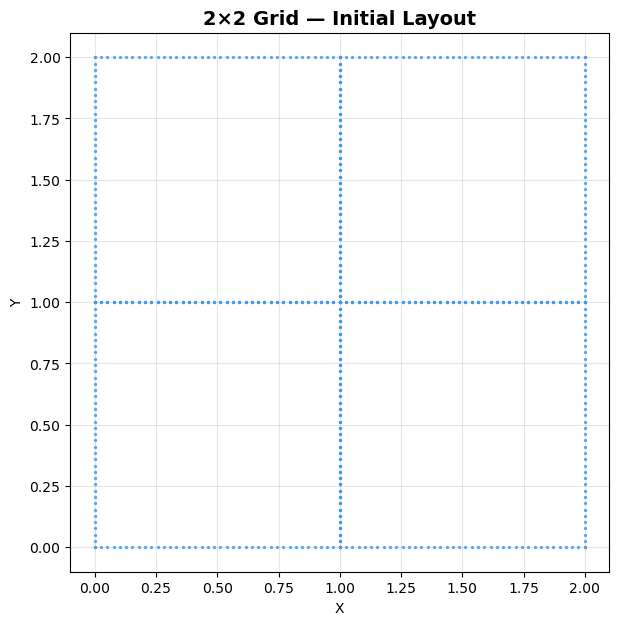

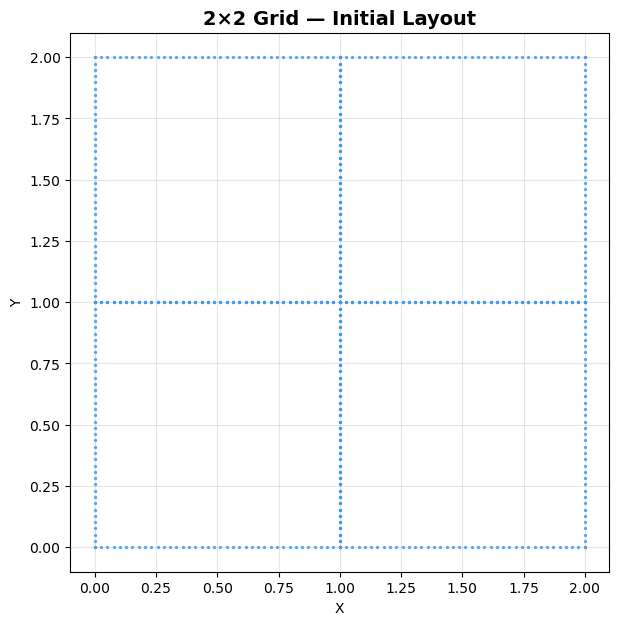

In [3]:
vd.plot_map_2d(map_points, title='2×2 Grid — Initial Layout')

### Create the underlying VDERM grid

`make_initial_grid_2d` automatically computes a grid sized to cover the point
cloud.  The default 2× padding keeps zero-flux boundary effects well away from
the object — analogous to `make_initial_grid` in the 3-D pipeline.

In [4]:
grid_params = vd.make_initial_grid_2d(map_points, max_points=4096)
vd.print_grid_info_2d(grid_params)

2D GRID INFORMATION

Grid dimensions : 64 × 64 = 4,096 points
Grid spacing (h): 0.063492

Grid size  : [4.0000, 4.0000]
Object size: [2.0000, 2.0000]
Ratio      : [2.00x, 2.00x]

Grid bounds:
  x: [-1.0000, 3.0000]
  y: [-1.0000, 3.0000]

Object bounds:
  x: [0.0000, 2.0000]
  y: [0.0000, 2.0000]

Object margins:
  x: min=1.0000, max=1.0000
  y: min=1.0000, max=1.0000


### Assign the density field

`set_density` accepts either a callable `f(x, y) → float` (evaluated at every
grid node) or a pre-built NumPy array of shape `(L, M)`.  The same options
exist in the 3-D API: `f(x, y, z)` or an `(L, M, N)` array.

Below we show **Option 1** (function) then **Option 2** (array).

In [30]:
def quadrant_density(x, y):
    """Return density based on which 1×1 region contains (x, y)."""
    if y>=0 and y<=2.0 and x >= 0 and x<=2.0:
        if x >= 1.0 and x<=2.0:
            return 10.0 if y >= 1.0 else 5.0   # D or B
        elif x>=0:
            return 2.0  if y >= 1.0 else 1.0   # C or A
    else:
        return np.mean([1,2,5,10])
# Option 1: set density with a function
grid = vd.VDERMGrid2D(
    shape=grid_params['shape'],
    h=grid_params['h'],
    min_bounds=grid_params['min_bounds'],
)
grid.set_density(quadrant_density)

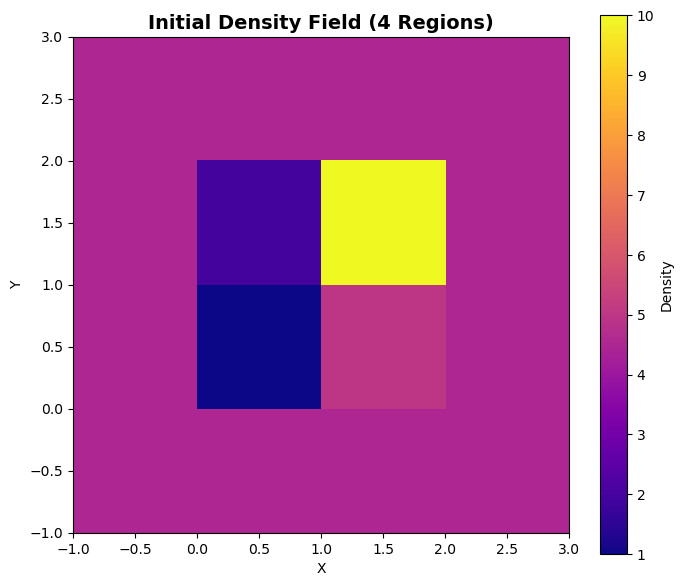

In [33]:
fig = vd.plot_density_field_2d(grid, title='Initial Density Field (4 Regions)')

In [34]:
# Option 2: build the density array directly (equivalent result)
L, M  = grid_params['shape']
x0, y0 = grid_params['min_bounds']
h = grid_params['h']

rho_array = np.array([[quadrant_density(x0 + i * h, y0 + j * h)
                        for j in range(M)]
                       for i in range(L)])

print(f"Density array shape : {rho_array.shape}")
print(f"Unique density values: {np.unique(rho_array)}")

# Uncomment to use the array instead of the function:
# grid.set_density(rho_array)

Density array shape : (64, 64)
Unique density values: [ 1.   2.   4.5  5.  10. ]


### Run the VDERM deformation

`run_VDERM` is dimension-agnostic: it works unchanged with both `VDERMGrid`
(3-D) and `VDERMGrid2D` (2-D).

The algorithm alternates between heat-equation density diffusion and Lagrangian
node advection until the relative density change ε falls below `max_eps`
(default 0.01).

In [35]:
deformed_grid = vd.run_VDERM(grid, n_max=100)

  ⚠ Warning: Very small timestep (0.000645)
    This may indicate strong density gradients.
    Expect longer computation time.


Deforming: 100%|██████████| 100/100 [00:00<00:00, 467.83it/s, ε=6.374e-02, target=1.000e-02]


### Apply the deformation to the map boundary

The grid displacement field is interpolated to the original map boundary
points.  High-density regions expand; low-density regions contract —
equalising the represented area weight.

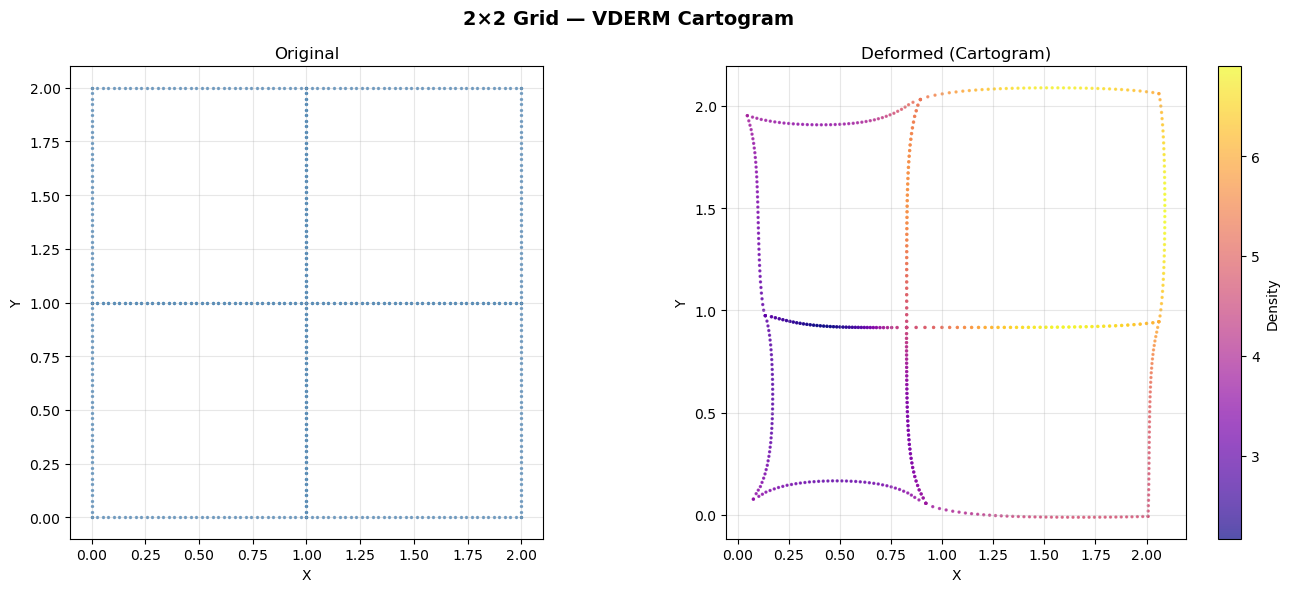

In [36]:
displacement  = deformed_grid.get_displacement_field()
deformed_map  = vd.interpolate_to_map_2d(map_points, grid_params, displacement)
densities     = vd.interpolate_densities_2d(map_points, deformed_grid)

fig = vd.plot_map_before_after(
    map_points, deformed_map,
    densities=densities,
    title='2×2 Grid — VDERM Cartogram',
)

### Continue the deformation (optional)

The grid object is updated in place, so calling `run_VDERM` again continues
from the current state — useful for pushing ε lower without restarting.

  ⚠ Warning: Very small timestep (0.000907)
    This may indicate strong density gradients.
    Expect longer computation time.


Converged:  69%|██████▊   | 343/500 [00:01<00:00, 297.99it/s, ε=9.960e-03, target=1.000e-02]



Converged at iteration 360


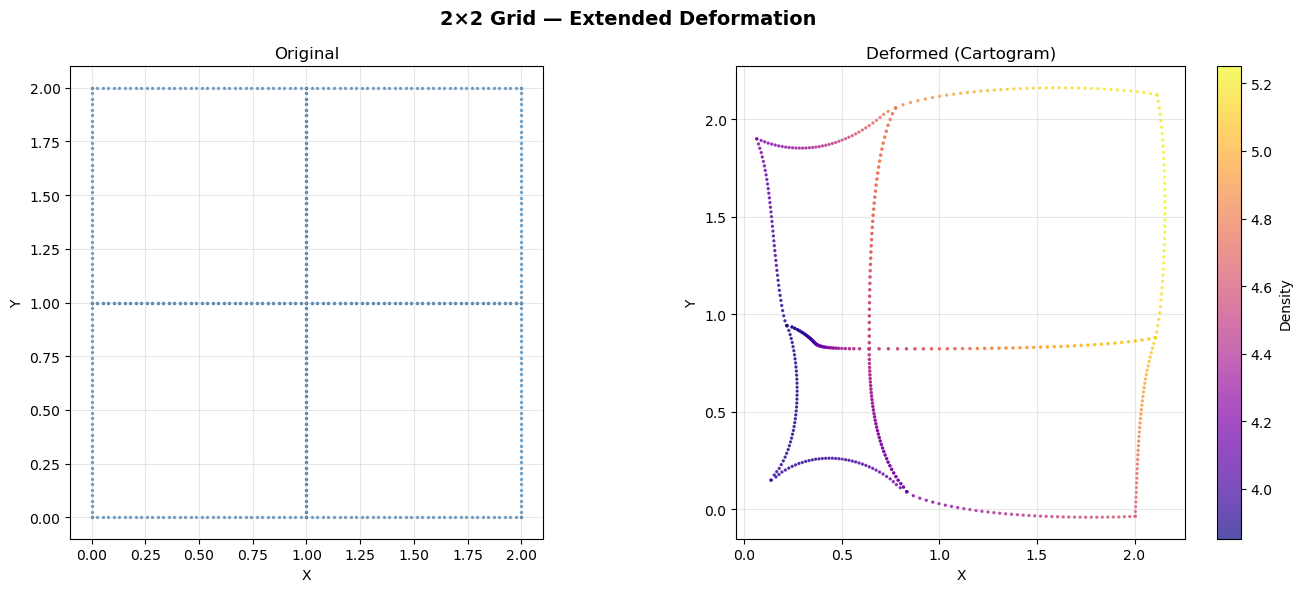

In [37]:
deformed_grid = vd.run_VDERM(grid, n_max=500)

deformed_map2 = vd.interpolate_to_map_2d(
    map_points, grid_params, deformed_grid.get_displacement_field()
)
densities2 = vd.interpolate_densities_2d(map_points, deformed_grid)

fig = vd.plot_map_before_after(
    map_points, deformed_map2,
    densities=densities2,
    title='2×2 Grid — Extended Deformation',
)

### Export the deformed map

`write_csv_2d` saves coordinates and optional densities to a space-delimited
file.  `read_csv_2d` reads them back — the 2-D equivalents of `write_xyz` /
`read_xyz` from the 3-D pipeline.

In [38]:
vd.write_csv_2d('deformed_2x2_grid.csv', deformed_map2, densities=densities2)
print("Saved: deformed_2x2_grid.csv  (columns: x  y  rho)")

pts_check, rho_check = vd.read_csv_2d('deformed_2x2_grid.csv')
print(f"Re-loaded {len(pts_check)} points, "
      f"density range [{rho_check.min():.3f}, {rho_check.max():.3f}]")

Saved: deformed_2x2_grid.csv  (columns: x  y  rho)
Re-loaded 640 points, density range [3.853, 5.250]
